# True Parameters at 1 PA Model

```python
m1 = 1e6
m2 = 10
a = 0.8 
e0 = 0.4 
xI0 = 1.0
dist = 0.4

qS = xp.pi/4
phiS = 1.0
qK = 1
phiK = xp.pi/3

Phi_phi0 = 0.9
Phi_theta0 = 0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p = 0.0
dev_0_e = 0.0
dev_1_p = 0.0
dev_1_e = 0.0
dev_2_p = 0.0
dev_2_e = 0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included = True

p0 = 7.5

best_fit_0pa_vs_1pa= best_fit = [13.81561299, 10.00055693,  0.80008266,  7.49954817,  0.39998251, 0.78536073,  0.99998866,  0.90006928,  0.39977347]

best_fit_with_deviation = [ 1.38157246e+01 , 1.00042793e+01 , 8.00138681e-01 , 7.49924060e+00,3.99933604e-01 , 7.85947492e-01,  9.99634868e-01,  9.66081240e-01, 3.41367413e-01, -2.40188581e-04, -6.24286978e-05]

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit_0pa_vs_1pa=  [13.81561299, 10.00055693,  0.80008266,  7.49954817,
                                   0.39998251, 0.78536073,  0.99998866,  0.90006928,  0.39977347]

best_fit_with_deviation = [ 1.38157246e+01 , 1.00042793e+01 , 8.00138681e-01 , 7.49924060e+00,
                           3.99933604e-01 , 7.85947492e-01,  9.99634868e-01,  9.66081240e-01,
                           3.41367413e-01, -2.40188581e-04, -6.24286978e-05]

#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]

m1 = 1e6
m2 = 10
a = 0.8 # 0.95
e0 = 0.4 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

print(use_gpu)
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

der_order = 8
Ndelta=16

True


## Fisher at Best FIT 0PA With Deviation

waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000214.0649443562), 10.0042793, 0.800138681, 7.4992406, 0.399933604, 1.0, 0.4, 0.785947492, 0.999634868, 1, 1.0471975511965976, 0.96608124, 0.5, 0.341367413, 0.0, False, False, False, True, -0.000240188581, -6.24286978e-05, 0.0, 0.0, 0.0, 0.0)
SNR:  136.9132670934827
Body is not plunging, Fisher should be stable.
waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000214.0649443562), 10.0042793, 0.800138681, 7.4992406, 0.399933604, 1.0, 0.4, 0.785947492, 0.999634868, 1, 1.0471975511965976, 0.96608124, 0.5, 0.341367413, 0.0, False, False, False, True, -0.000240188581, -6.24286978e-05, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.9132670934827
calculating stable deltas...
Gamma_ii for m1: 22296.136868839003
Gamma_ii for m1: 22296.1370315417
Gamma_ii for m1: 22296.137793711052
Gamma_ii for m1: 22296.137193319126
Gamma_ii for m1: 22296.13595509728
Gamma_ii for m1: 222

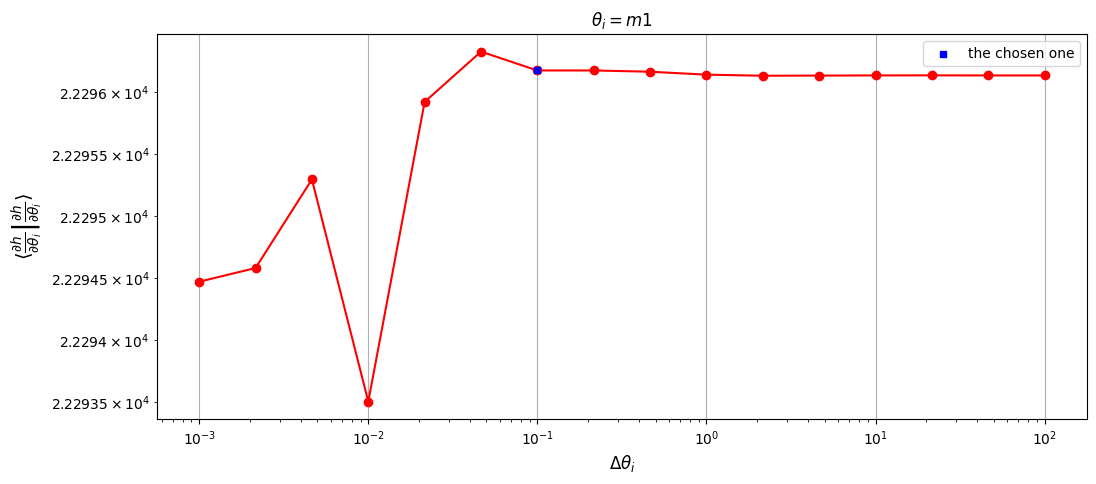

Gamma_ii for m2: 14228470139150.736
Gamma_ii for m2: 14228469975345.98
Gamma_ii for m2: 14228471130496.629
Gamma_ii for m2: 14228469274279.76
Gamma_ii for m2: 14228469205145.729
Gamma_ii for m2: 14228464098870.615
Gamma_ii for m2: 14228483155355.822
Gamma_ii for m2: 14228550743123.97
Gamma_ii for m2: 14228573384710.637
Gamma_ii for m2: 14228558395535.875
Gamma_ii for m2: 14228943839446.107
Gamma_ii for m2: 14227960794159.334
Gamma_ii for m2: 14221823946848.484
Gamma_ii for m2: 14226908258814.6
Gamma_ii for m2: 14225928482674.268
Gamma_ii for m2: 14223491879695.71
[np.float64(1.1512464526628901e-08), np.float64(8.118585882088238e-08), np.float64(1.3045794550057712e-07), np.float64(4.858852365157994e-09), np.float64(3.588774640606895e-07), np.float64(1.3393195183885847e-06), np.float64(4.750151253535057e-06), np.float64(1.591275952538237e-06), np.float64(1.0534570224922796e-06), np.float64(2.7088722436578688e-05), np.float64(6.909249336538682e-05), np.float64(0.00043150916041324763), np.

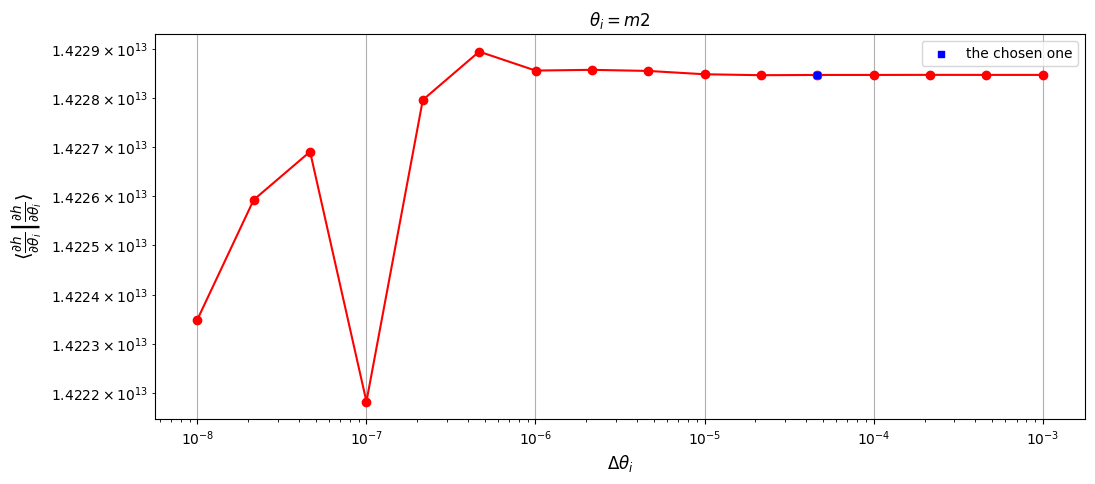

Gamma_ii for a: 1823553086803343.8
Gamma_ii for a: 1823553102276633.0
Gamma_ii for a: 1823552740046283.0
Gamma_ii for a: 1823553574164514.0
Gamma_ii for a: 1823554039855273.0
Gamma_ii for a: 1823553011244811.8
Gamma_ii for a: 1823539886954968.0
Gamma_ii for a: 1823561402380997.2
Gamma_ii for a: 1823547088487134.2
Gamma_ii for a: 1823545689003024.2
Gamma_ii for a: 1823586953056970.0
Gamma_ii for a: 1823755749761017.0
Gamma_ii for a: 1823998286115258.8
Gamma_ii for a: 1823837485466041.5
Gamma_ii for a: 1825439279257940.8
Gamma_ii for a: 1821772394424794.5
[np.float64(8.485241932731336e-09), np.float64(1.9863990881382809e-07), np.float64(4.5741361417481945e-07), np.float64(2.553753542927413e-07), np.float64(5.640694045674273e-07), np.float64(7.197149860903537e-06), np.float64(1.1798575030792835e-05), np.float64(7.849478608679751e-06), np.float64(7.674521776118103e-07), np.float64(2.262796072135579e-05), np.float64(9.255444654204322e-05), np.float64(0.00013296961739931376), np.float64(8.81

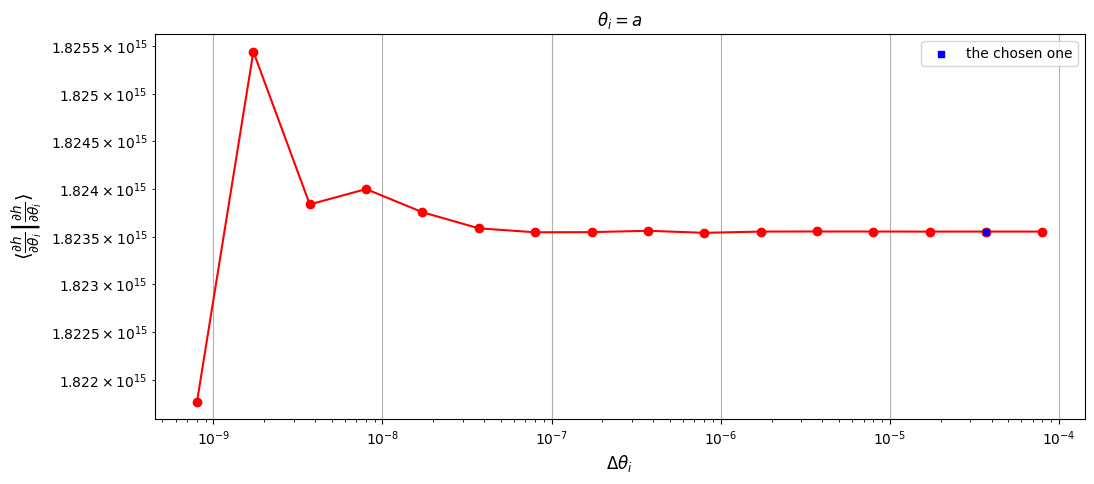

Gamma_ii for p0: 1176233606061220.8
Gamma_ii for p0: 1176233595511320.2
Gamma_ii for p0: 1176233612121502.0
Gamma_ii for p0: 1176233604765660.8
Gamma_ii for p0: 1176233415175222.8
Gamma_ii for p0: 1176233617653440.2
Gamma_ii for p0: 1176234519445881.8
Gamma_ii for p0: 1176233295680818.5
Gamma_ii for p0: 1176231403006013.0
Gamma_ii for p0: 1176239123021870.8
Gamma_ii for p0: 1176252956662578.8
Gamma_ii for p0: 1176212496570187.8
Gamma_ii for p0: 1176231235418944.8
Gamma_ii for p0: 1176387509792618.2
Gamma_ii for p0: 1176522612481259.5
Gamma_ii for p0: 1175849734069922.8
[np.float64(8.969222219344837e-09), np.float64(1.4121498976756167e-08), np.float64(6.25372478748853e-09), np.float64(1.6118436660104307e-07), np.float64(1.7214115840689837e-07), np.float64(7.666774155929635e-07), np.float64(1.0404101531079934e-06), np.float64(1.6091007268323412e-06), np.float64(6.563304779317781e-06), np.float64(1.1760770189475777e-05), np.float64(3.439862483095599e-05), np.float64(1.5931262657147243e-05

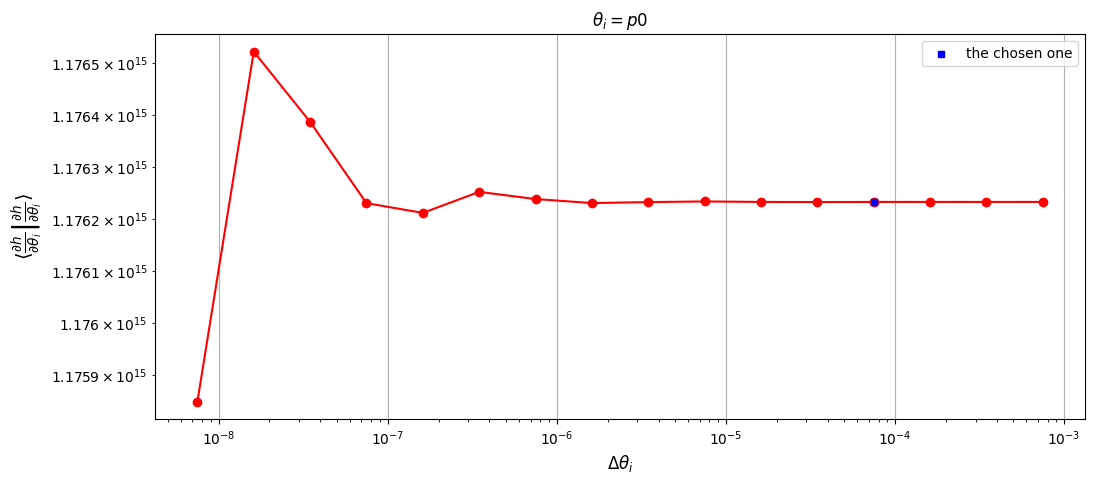

Gamma_ii for e0: 3820461204879846.0
Gamma_ii for e0: 3820460663533795.0
Gamma_ii for e0: 3820460811561458.0
Gamma_ii for e0: 3820460747403902.0
Gamma_ii for e0: 3820460671880174.0
Gamma_ii for e0: 3820458328535631.0
Gamma_ii for e0: 3820454444321484.5
Gamma_ii for e0: 3820457666874879.5
Gamma_ii for e0: 3820346671968126.0
Gamma_ii for e0: 3820472637295640.5
Gamma_ii for e0: 3820512132501901.5
Gamma_ii for e0: 3820705147209546.0
Gamma_ii for e0: 3823932653856470.0
Gamma_ii for e0: 3818294967523720.0
Gamma_ii for e0: 3829215179996516.0
Gamma_ii for e0: 3800264959172414.0
[np.float64(1.4169653836960946e-07), np.float64(3.874602313732403e-08), np.float64(1.679314623075153e-08), np.float64(1.976822548020951e-08), np.float64(6.133673872313106e-07), np.float64(1.0166890361101634e-06), np.float64(8.434993071487263e-07), np.float64(2.905362164327323e-05), np.float64(3.297113720559606e-05), np.float64(1.0337673299086257e-05), np.float64(5.051808506748248e-05), np.float64(0.0008440281090382256), 

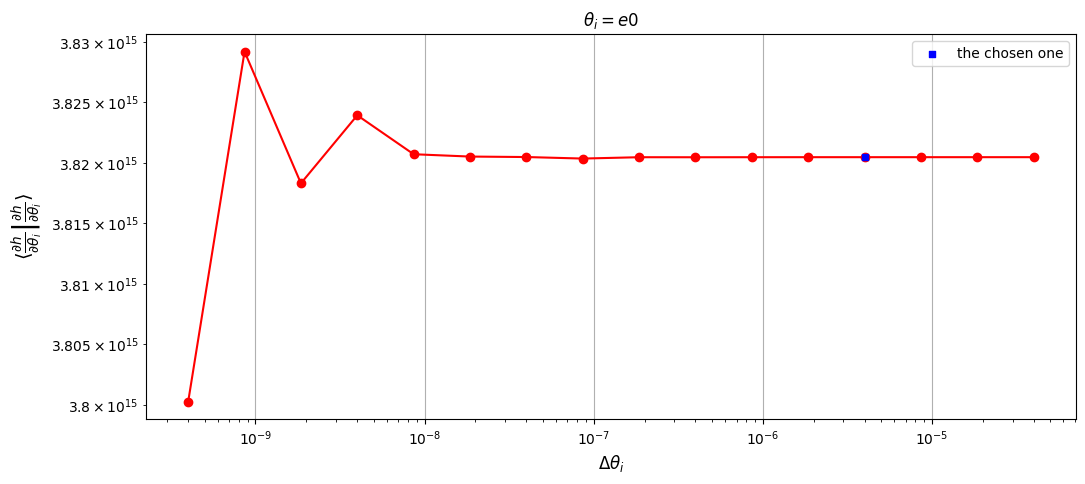

Gamma_ii for qS: 58842.8841145993
Gamma_ii for qS: 58842.88421138208
Gamma_ii for qS: 58842.88421159456
Gamma_ii for qS: 58842.88421159555
Gamma_ii for qS: 58842.88421159536
Gamma_ii for qS: 58842.88421159785
Gamma_ii for qS: 58842.884211596785
Gamma_ii for qS: 58842.88421158086
Gamma_ii for qS: 58842.88421160511
Gamma_ii for qS: 58842.884211626995
Gamma_ii for qS: 58842.884211563476
Gamma_ii for qS: 58842.88421145799
Gamma_ii for qS: 58842.88421189555
Gamma_ii for qS: 58842.88421277643
Gamma_ii for qS: 58842.884212504694
Gamma_ii for qS: 58842.88421036782
[np.float64(1.6447660803282917e-09), np.float64(3.610968310848553e-12), np.float64(1.681648085043985e-14), np.float64(3.2149154567017463e-15), np.float64(4.228850331507503e-14), np.float64(1.8052986795324754e-14), np.float64(2.7067115133545604e-13), np.float64(4.121274314301979e-13), np.float64(3.7194098822129437e-13), np.float64(1.0794696898854405e-12), np.float64(1.7926863188988741e-12), np.float64(7.436099451313204e-12), np.float6

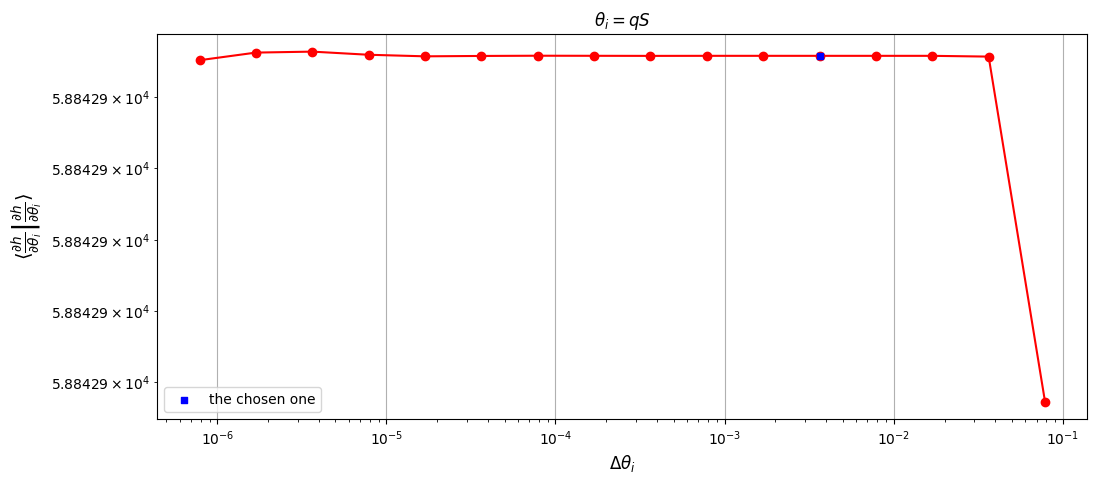

Gamma_ii for phiS: 1115197.2641575665
Gamma_ii for phiS: 1115197.2641213075
Gamma_ii for phiS: 1115197.2641212274
Gamma_ii for phiS: 1115197.2641212274
Gamma_ii for phiS: 1115197.2641212274
Gamma_ii for phiS: 1115197.2641212272
Gamma_ii for phiS: 1115197.2641212274
Gamma_ii for phiS: 1115197.2641212274
Gamma_ii for phiS: 1115197.264121227
Gamma_ii for phiS: 1115197.264121228
Gamma_ii for phiS: 1115197.2641212288
Gamma_ii for phiS: 1115197.2641212295
Gamma_ii for phiS: 1115197.264121238
Gamma_ii for phiS: 1115197.2641212419
Gamma_ii for phiS: 1115197.2641212223
Gamma_ii for phiS: 1115197.2641211879
[np.float64(3.251348450485137e-11), np.float64(7.182024561371643e-14), np.float64(0.0), np.float64(0.0), np.float64(2.0877978376080362e-16), np.float64(2.087797837608036e-16), np.float64(0.0), np.float64(4.1755956752160735e-16), np.float64(8.35119135043214e-16), np.float64(8.351191350432133e-16), np.float64(6.263393512824096e-16), np.float64(7.516072215388858e-15), np.float64(3.54925632393361

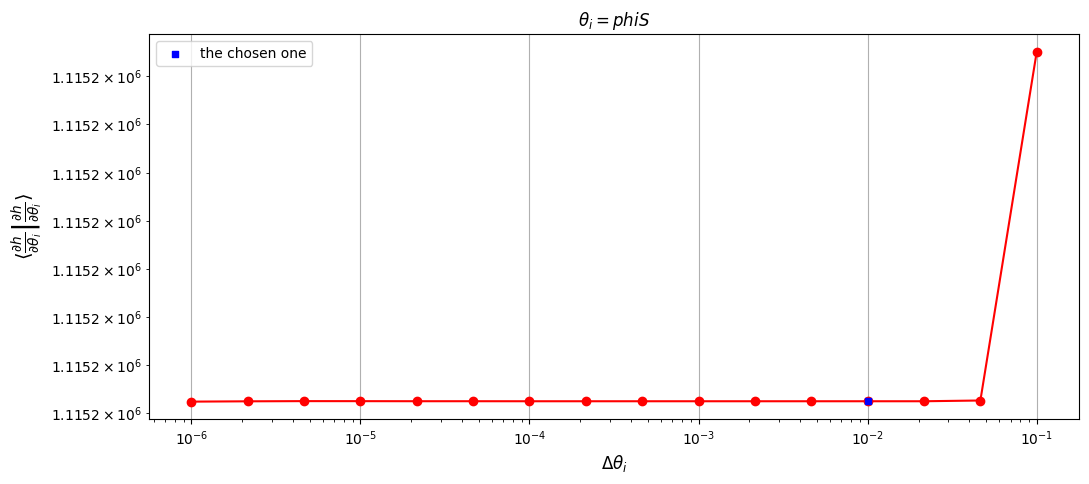

Gamma_ii for dev0p: 80.0328503414886
Gamma_ii for dev0p: 20.053921671678623
Gamma_ii for dev0p: 191.0708403615542
Gamma_ii for dev0p: 517.9387694581229
Gamma_ii for dev0p: 2502.1278224969506
Gamma_ii for dev0p: 17090.314051326022
Gamma_ii for dev0p: 11694.49554057316
Gamma_ii for dev0p: 115506.41758257143
Gamma_ii for dev0p: 1733735.5253404034
Gamma_ii for dev0p: 1609479.5452311465
Gamma_ii for dev0p: 8845520.508863162
Gamma_ii for dev0p: 53522869.068036206
Gamma_ii for dev0p: 396240709.3105532
Gamma_ii for dev0p: 2095918914.028139
Gamma_ii for dev0p: 19834147411.166527
Gamma_ii for dev0p: 79472971085.47769
[np.float64(2.9908827635701747), np.float64(0.8950445728205751), np.float64(0.6310937670075248), np.float64(0.793000675344693), np.float64(0.8535938067034636), np.float64(0.46139814171825383), np.float64(0.8987545819069908), np.float64(0.9333771409224063), np.float64(0.0772025842002309), np.float64(0.8180458070705441), np.float64(0.8347338126134629), np.float64(0.8649233463134962), 

/home/svu/e1583490/scratch/packages_for_multi_inference/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/anaconda3/envs/few_gpu/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


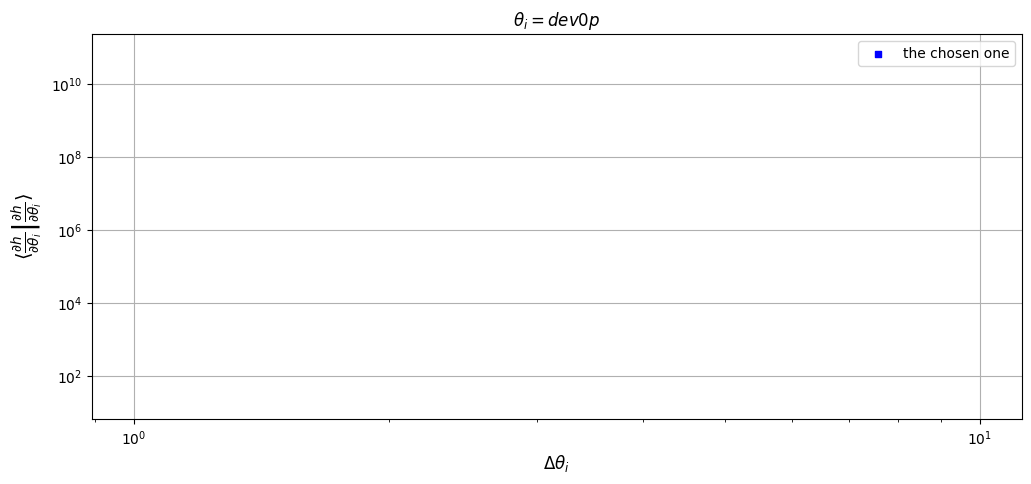

Gamma_ii for dev0e: 155.0711157392795
Gamma_ii for dev0e: 122.87715150902326
Gamma_ii for dev0e: 3068.3082629458836
Gamma_ii for dev0e: 1499.8213972107492
Gamma_ii for dev0e: 37166.58292521247
Gamma_ii for dev0e: 332190.28414308716
Gamma_ii for dev0e: 261511.41905865917
Gamma_ii for dev0e: 1159217.812415487
Gamma_ii for dev0e: 30960773.986694094
Gamma_ii for dev0e: 464190613.86326456
Gamma_ii for dev0e: 232490655.8612116
Gamma_ii for dev0e: 314588778.9419744
Gamma_ii for dev0e: 17302851847.383923
Gamma_ii for dev0e: 63029787867.42572
Gamma_ii for dev0e: 433278191627.5792
Gamma_ii for dev0e: 2262974140321.6465
[np.float64(0.2620012250844871), np.float64(0.9599528010294999), np.float64(1.0457824302627525), np.float64(0.9596459701385859), np.float64(0.8881165864887145), np.float64(0.27027066481014406), np.float64(0.7744070042249073), np.float64(0.9625585002198691), np.float64(0.9333015940821799), np.float64(0.9965990123077004), np.float64(0.26096964855795357), np.float64(0.981818674648737

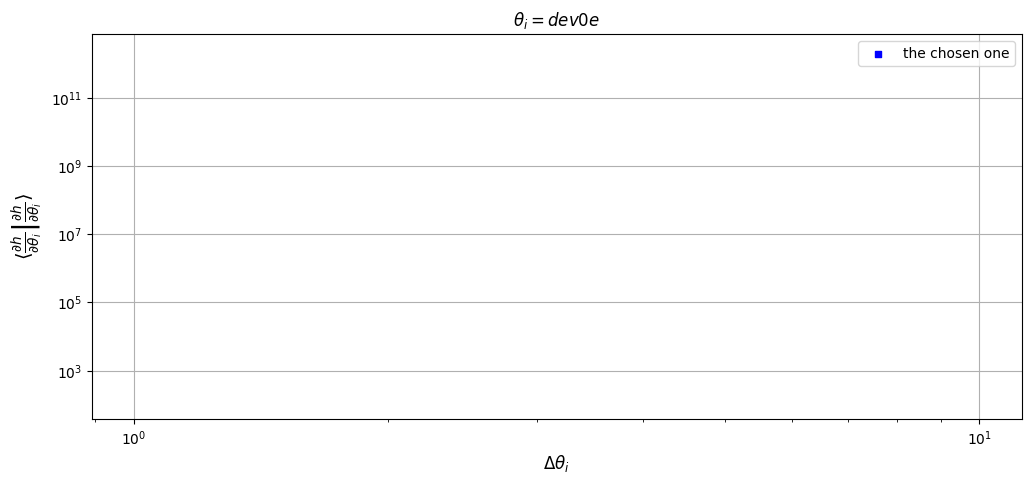

stable deltas: {'m1': 0.10002140649443561, 'm2': 4.643575108722344e-05, 'a': 3.713914767071257e-05, 'p0': 7.499240600000001e-05, 'e0': 3.999336039999998e-06, 'qS': 0.0036480451026731702, 'phiS': 0.009996348679999996, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': -2.401885810000003e-08, 'dev0e': -1.3449855219383719e-09}
Time taken to compute stable deltas is 348.89589977264404 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 23.299338579177856 seconds


In [5]:
logm1_bf = best_fit_with_deviation[0]
m1_bf = np.exp(logm1_bf)
m2_bf = best_fit_with_deviation[1]
a_bf = best_fit_with_deviation[2]
p0_bf = best_fit_with_deviation[3]
e0_bf  = best_fit_with_deviation[4]
qS_bf = best_fit_with_deviation[5]
phiS_bf = best_fit_with_deviation[6]
Phi_phi0_bf = best_fit_with_deviation[7]
Phi_r0_bf = best_fit_with_deviation[8]
dev_0_p_bf =best_fit_with_deviation[9]
dev_0_e_bf =best_fit_with_deviation[10]

evolve_1PA_bf = False
deviation_included_bf = True

pars_list_com = [m1_bf, m2_bf, a_bf, p0_bf, e0_bf, xI0, dist, qS_bf, phiS_bf, qK, phiK, Phi_phi0_bf, Phi_theta0, Phi_r0_bf,\
             chi2,evolve_1PA_bf,evolve_primary,evolve_2PA,deviation_included_bf,dev_0_p_bf,dev_0_e_bf,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args_bf ={"chi2":chi2,"evolve_1PA":evolve_1PA_bf,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,
                    "deviation_included":deviation_included_bf,"dev0p":dev_0_p_bf,"dev0e":dev_0_e_bf,
                    "dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

add_args_bf = [chi2, evolve_1PA_bf, evolve_primary, evolve_2PA,deviation_included_bf,dev_0_p_bf,dev_0_e_bf,dev_1_p,dev_1_e,dev_2_p,dev_2_e]


sef_bf = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef_bf.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict_bf = {
    'm1': m1_bf,
    'm2': m2_bf,
    'a': a_bf,
    'p0': p0_bf,
    'e0': e0_bf,
    'xI0': xI0,
    'dist': dist,
    'qS': qS_bf,
    'phiS': phiS_bf,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0_bf,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0_bf
}


Fisher_bf = sef_bf(wave_params = param_dict_bf,param_names=param_names, add_param_args=add_param_args_bf,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )

In [ ]:
logm1_bf = best_fit_with_deviation[0]
m1_bf = np.exp(logm1_bf)
m2_bf = best_fit_with_deviation[1]
a_bf = best_fit_with_deviation[2]
p0_bf = best_fit_with_deviation[3]
e0_bf  = best_fit_with_deviation[4]
qS_bf = best_fit_with_deviation[5]
phiS_bf = best_fit_with_deviation[6]
Phi_phi0_bf = best_fit_with_deviation[7]
Phi_r0_bf = best_fit_with_deviation[8]
dev_0_p_bf =best_fit_with_deviation[9]
dev_0_e_bf =best_fit_with_deviation[10]

evolve_1PA_bf = False
deviation_included_bf = True

pars_list_com = [m1_bf, m2_bf, a_bf, p0_bf, e0_bf, xI0, dist, qS_bf, phiS_bf, qK, phiK, Phi_phi0_bf, Phi_theta0, Phi_r0_bf,\
             chi2,evolve_1PA_bf,evolve_primary,evolve_2PA,deviation_included_bf,0,0,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args_bf ={"chi2":chi2,"evolve_1PA":evolve_1PA_bf,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,
                    "deviation_included":deviation_included_bf,"dev0p":0,"dev0e":0,
                    "dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

add_args_bf = [chi2, evolve_1PA_bf, evolve_primary, evolve_2PA,deviation_included_bf,0,0,dev_1_p,dev_1_e,dev_2_p,dev_2_e]



                   

SNR = sef_bf.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict_bf = {
    'm1': m1_bf,
    'm2': m2_bf,
    'a': a_bf,
    'p0': p0_bf,
    'e0': e0_bf,
    'xI0': xI0,
    'dist': dist,
    'qS': qS_bf,
    'phiS': phiS_bf,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0_bf,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0_bf
}


Fisher_bf = sef_bf(wave_params = param_dict_bf,param_names=param_names, add_param_args=add_param_args_bf,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )

## Fisher Best FIT Point 0PA without Deviation

waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000102.437282066), 10.00055693, 0.80008266, 7.49954817, 0.39998251, 1.0, 0.4, 0.78536073, 0.99998866, 1, 1.0471975511965976, 0.90006928, 0.5, 0.39977347, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  136.81223981118265
Body is not plunging, Fisher should be stable.
waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000102.437282066), 10.00055693, 0.80008266, 7.49954817, 0.39998251, 1.0, 0.4, 0.78536073, 0.99998866, 1, 1.0471975511965976, 0.90006928, 0.5, 0.39977347, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.81223981118265
calculating stable deltas...
Gamma_ii for m1: 22245.19474228892
Gamma_ii for m1: 22245.194744581135
Gamma_ii for m1: 22245.19474446373
Gamma_ii for m1: 22245.194744598924
Gamma_ii for m1: 22245.194744881
Gamma_ii for m1: 22245.19474579063
Gamma_ii for m1: 22245.194747430978
Gamma

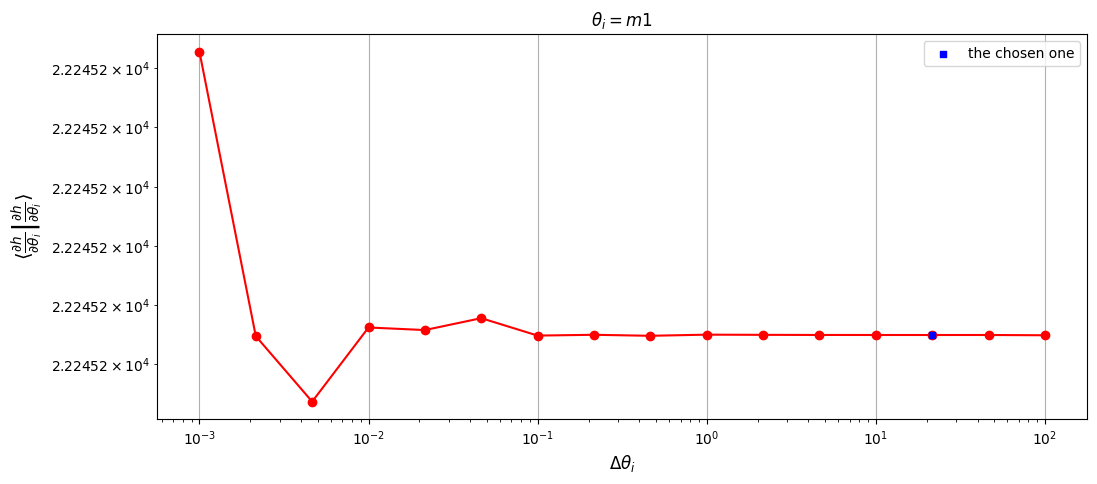

Gamma_ii for m2: 14185105601639.025
Gamma_ii for m2: 14185105601677.277
Gamma_ii for m2: 14185105601088.834
Gamma_ii for m2: 14185105600720.535
Gamma_ii for m2: 14185105599862.812
Gamma_ii for m2: 14185105595856.72
Gamma_ii for m2: 14185105606379.188
Gamma_ii for m2: 14185105605771.629
Gamma_ii for m2: 14185105630257.54
Gamma_ii for m2: 14185105554593.23
Gamma_ii for m2: 14185105704243.127
Gamma_ii for m2: 14185106111147.477
Gamma_ii for m2: 14185106989152.148
Gamma_ii for m2: 14185108103213.994
Gamma_ii for m2: 14185107120326.615
Gamma_ii for m2: 14185101581206.098
[np.float64(2.696628012446873e-12), np.float64(4.148318496337678e-11), np.float64(2.596377062616243e-11), np.float64(6.046642728259248e-11), np.float64(2.8241536658318045e-10), np.float64(7.417968599502663e-10), np.float64(4.2830741669120663e-11), np.float64(1.7261704490955874e-09), np.float64(5.334067364006988e-09), np.float64(1.054979071742912e-08), np.float64(2.8685322931042865e-08), np.float64(6.189623191044249e-08), np

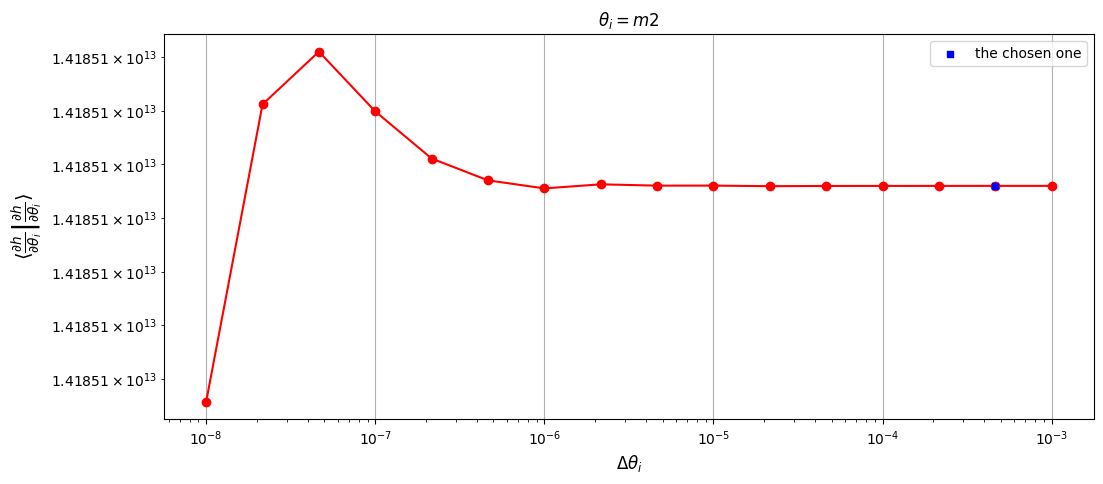

Gamma_ii for a: 1815422315399850.8
Gamma_ii for a: 1815422371452916.0
Gamma_ii for a: 1815422373274389.2
Gamma_ii for a: 1815422775922959.0
Gamma_ii for a: 1815422135239822.2
Gamma_ii for a: 1815423649117716.0
Gamma_ii for a: 1815419558805866.2
Gamma_ii for a: 1815429235207526.5
Gamma_ii for a: 1815380499849717.2
Gamma_ii for a: 1815337586982903.8
Gamma_ii for a: 1815337705430193.0
Gamma_ii for a: 1815281203805409.5
Gamma_ii for a: 1815800935458867.5
Gamma_ii for a: 1813072665628914.5
Gamma_ii for a: 1816678637420985.2
Gamma_ii for a: 1820915066207415.2
[np.float64(3.087604633027613e-08), np.float64(1.0033330407373449e-09), np.float64(2.217932787283083e-07), np.float64(3.5291138315076455e-07), np.float64(8.338978587646661e-07), np.float64(2.2530945146589123e-06), np.float64(5.330090246753058e-06), np.float64(2.68458088060792e-05), np.float64(2.3639055964693215e-05), np.float64(6.524807417137338e-08), np.float64(3.112554939975941e-05), np.float64(0.0002862272197952468), np.float64(0.001

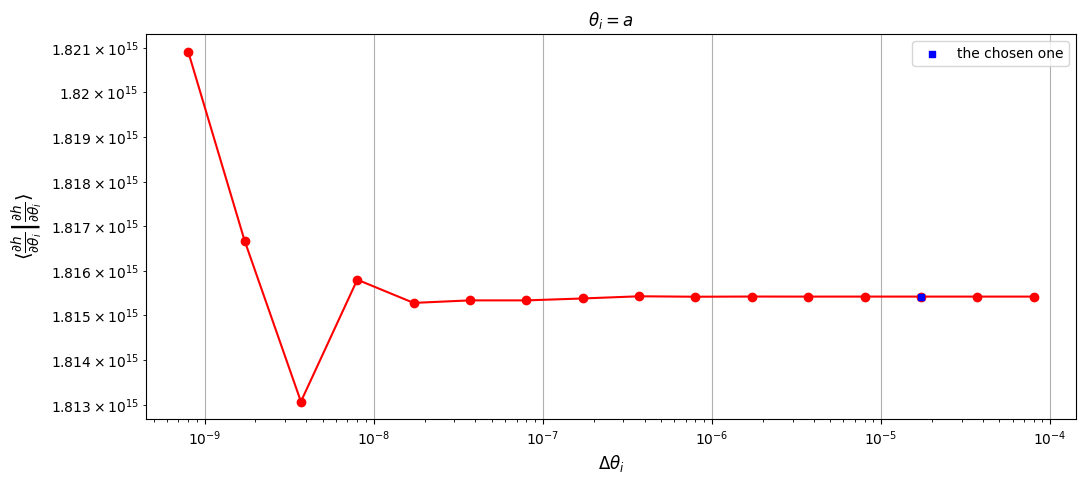

Gamma_ii for p0: 1172871398523672.8
Gamma_ii for p0: 1172871397668811.0
Gamma_ii for p0: 1172871378377061.8
Gamma_ii for p0: 1172871270560472.5
Gamma_ii for p0: 1172871306733653.5
Gamma_ii for p0: 1172871121758617.5
Gamma_ii for p0: 1172871591537973.5
Gamma_ii for p0: 1172871487924324.8
Gamma_ii for p0: 1172872601095881.2
Gamma_ii for p0: 1172874499848679.0
Gamma_ii for p0: 1172876040401466.8
Gamma_ii for p0: 1172860649167360.8
Gamma_ii for p0: 1172820692841609.0
Gamma_ii for p0: 1172938154164456.5
Gamma_ii for p0: 1173046863093074.0
Gamma_ii for p0: 1172346420903843.8
[np.float64(7.288623046815838e-10), np.float64(1.6448307636848115e-08), np.float64(9.192533908557448e-08), np.float64(3.0841560188508e-08), np.float64(1.577113056741018e-07), np.float64(4.0053775655354013e-07), np.float64(8.834185997083875e-08), np.float64(9.49098440410238e-07), np.float64(1.6188882936707822e-06), np.float64(1.313483040562991e-06), np.float64(1.3122815670324153e-05), np.float64(3.4068571603166756e-05), n

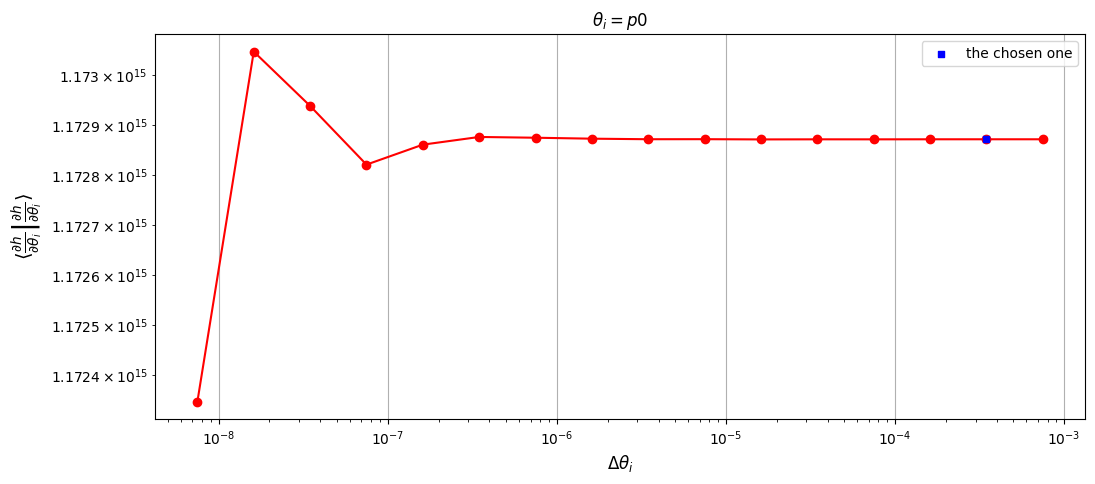

Gamma_ii for e0: 3817398277458968.0
Gamma_ii for e0: 3817397829517224.0
Gamma_ii for e0: 3817398372111420.5
Gamma_ii for e0: 3817400261606632.5
Gamma_ii for e0: 3817393325224320.5
Gamma_ii for e0: 3817401199265938.0
Gamma_ii for e0: 3817399573638052.0
Gamma_ii for e0: 3817413790253499.5
Gamma_ii for e0: 3817399277427204.0
Gamma_ii for e0: 3817523690559258.0
Gamma_ii for e0: 3817462126796173.5
Gamma_ii for e0: 3816939405672211.5
Gamma_ii for e0: 3818340791387627.0
Gamma_ii for e0: 3815255597841037.0
Gamma_ii for e0: 3822609433953081.0
Gamma_ii for e0: 3817136137306638.0
[np.float64(1.1734216972000793e-07), np.float64(1.4213716872307687e-07), np.float64(4.949691105236019e-07), np.float64(1.8170467963482382e-06), np.float64(2.0626707035703055e-06), np.float64(4.258469292096522e-07), np.float64(3.7241483969585413e-06), np.float64(3.8017574900577722e-06), np.float64(3.2590009162660564e-05), np.float64(1.6126882478377785e-05), np.float64(0.00013694771344423325), np.float64(0.0003670143111836

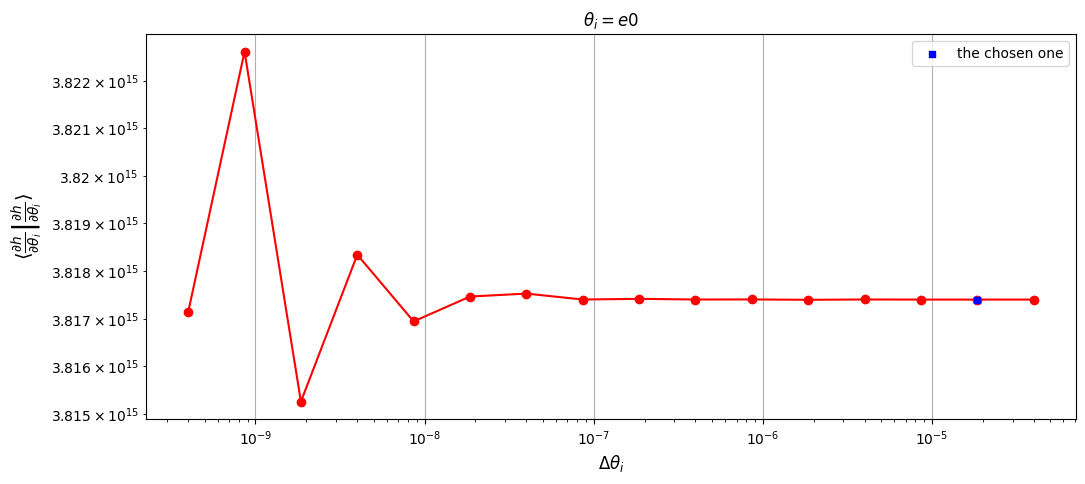

Gamma_ii for qS: 57457.0008828078
Gamma_ii for qS: 57457.000978979675
Gamma_ii for qS: 57457.00097919067
Gamma_ii for qS: 57457.00097919101
Gamma_ii for qS: 57457.00097919114
Gamma_ii for qS: 57457.00097918949
Gamma_ii for qS: 57457.0009791986
Gamma_ii for qS: 57457.00097919772
Gamma_ii for qS: 57457.00097918372
Gamma_ii for qS: 57457.00097919098
Gamma_ii for qS: 57457.000979077384
Gamma_ii for qS: 57457.00097921636
Gamma_ii for qS: 57457.0009792472
Gamma_ii for qS: 57457.00097886813
Gamma_ii for qS: 57457.000978284734
Gamma_ii for qS: 57457.00097246381
[np.float64(1.6738060537052447e-09), np.float64(3.6722329961169025e-12), np.float64(5.951755261129466e-15), np.float64(2.2793956319219183e-15), np.float64(2.874571158034946e-14), np.float64(1.5854462950921506e-13), np.float64(1.532260397014003e-14), np.float64(2.4364206643435204e-13), np.float64(1.2637982448100449e-13), np.float64(1.977122444514854e-12), np.float64(2.4188186647400806e-12), np.float64(5.366710382264258e-13), np.float64(6

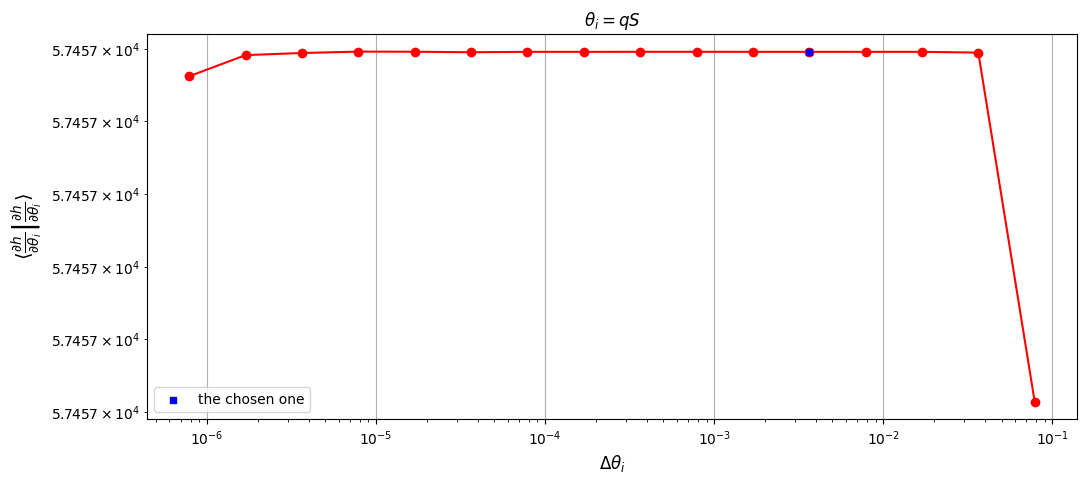

Gamma_ii for phiS: 1108794.0786808021
Gamma_ii for phiS: 1108794.0786439069
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.078643825
Gamma_ii for phiS: 1108794.0786438237
Gamma_ii for phiS: 1108794.0786438235
Gamma_ii for phiS: 1108794.0786438263
Gamma_ii for phiS: 1108794.0786438233
Gamma_ii for phiS: 1108794.078643833
Gamma_ii for phiS: 1108794.0786438105
Gamma_ii for phiS: 1108794.0786438813
[np.float64(3.327513722033128e-11), np.float64(7.349491384236676e-14), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(4.199709362420959e-16), np.float64(1.0499273406052409e-15), np.float64(2.0998546812104821e-16), np.float64(2.5198256174525723e-15), np.float64(2.729811085573627e-15), np.float64(8.819389661083949e-15), np.float64(2.036859040774

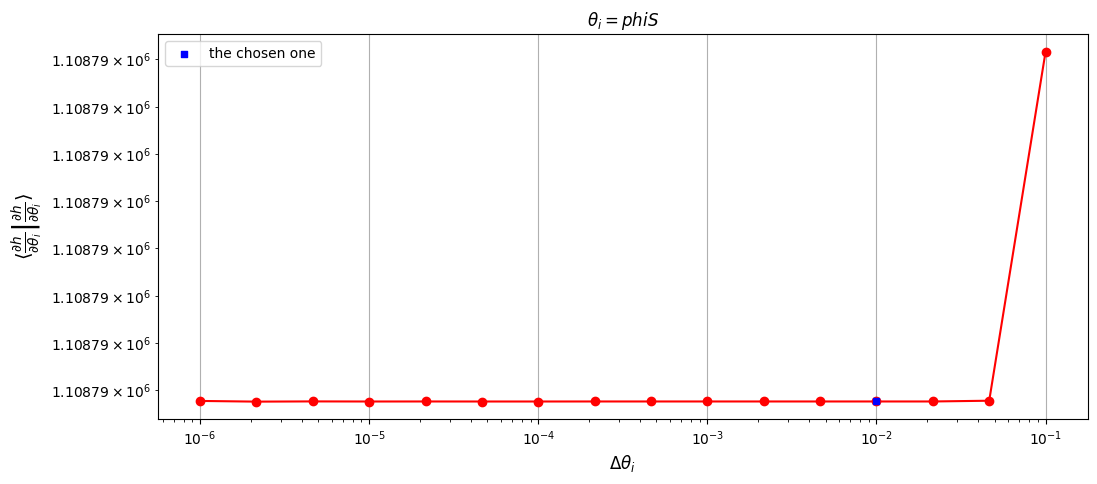

stable deltas: {'m1': 21.546553844659197, 'm2': 0.0004641847337619687, 'a': 1.723725837596985e-05, 'p0': 0.0003480981904301315, 'e0': 1.8565543520564136e-05, 'qS': 0.0036453215947259815, 'phiS': 0.009999886600000002, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 251.33067774772644 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 16.86961603164673 seconds


In [6]:
logm1_0v1_bf = best_fit_0pa_vs_1pa[0]
m1_0v1_bf = np.exp(logm1_0v1_bf)
m2_0v1_bf = best_fit_0pa_vs_1pa[1]
a_0v1_bf = best_fit_0pa_vs_1pa[2]
p0_0v1_bf = best_fit_0pa_vs_1pa[3]
e0_0v1_bf  = best_fit_0pa_vs_1pa[4]
qS_0v1_bf = best_fit_0pa_vs_1pa[5]
phiS_0v1_bf = best_fit_0pa_vs_1pa[6]
Phi_phi0_0v1_bf = best_fit_0pa_vs_1pa[7]
Phi_r0_0v1_bf = best_fit_0pa_vs_1pa[8]

evolve_1PA_0v1_bf = False
deviation_included_0v1_bf = True

pars_list_com = [m1_0v1_bf, m2_0v1_bf, a_0v1_bf, p0_0v1_bf, e0_0v1_bf, xI0, dist, qS_0v1_bf, phiS_0v1_bf, qK,
                  phiK, Phi_phi0_0v1_bf, Phi_theta0, Phi_r0_0v1_bf,chi2,evolve_1PA_0v1_bf,evolve_primary,
                  evolve_2PA,deviation_included_0v1_bf,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args_0v1_bf ={"chi2":chi2,"evolve_1PA":evolve_1PA_0v1_bf,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,
                    "deviation_included":deviation_included_0v1_bf,"dev0p":dev_0_p,"dev0e":dev_0_e,
                    "dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']

add_args_0v1_bf = [chi2, evolve_1PA_0v1_bf, evolve_primary, evolve_2PA,deviation_included_0v1_bf,
                   dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]


sef_0v1_bf = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef_0v1_bf.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict_0v1_bf = {
    'm1': m1_0v1_bf,
    'm2': m2_0v1_bf,
    'a': a_0v1_bf,
    'p0': p0_0v1_bf,
    'e0': e0_0v1_bf,
    'xI0': xI0,
    'dist': dist,
    'qS': qS_0v1_bf,
    'phiS': phiS_0v1_bf,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0_0v1_bf,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0_0v1_bf
}


Fisher_0v1_bf = sef_0v1_bf(wave_params = param_dict_0v1_bf,param_names=param_names, add_param_args=add_param_args_0v1_bf,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )

## Fisher True Point 1PA

waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Body is not plunging, Fisher should be stable.
waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.80016042169797
calculating stable deltas...
Gamma_ii for m1: 22246.887710786756
Gamma_ii for m1: 22246.887502381764
Gamma_ii for m1: 22246.887505623396
Gamma_ii for m1: 22246.889662757127
Gamma_ii for m1: 22246.894879859425
Gamma_ii for m1: 22246.896363042502
Gamma_ii for m1: 22246.905925225772
Gamma_ii for m1: 22246.835505785275
Gamma_ii for m1: 22246.800255818172
Gamma_ii for m1: 22246.904676301616
Gamma_ii for m1: 22247.204824477074
Gamma_ii

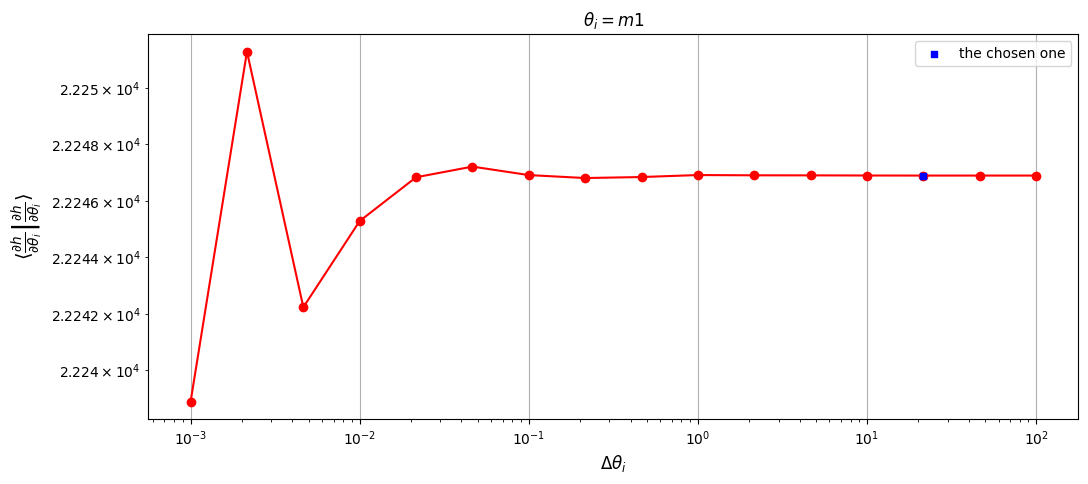

Gamma_ii for m2: 14185045793255.27
Gamma_ii for m2: 14185044620481.74
Gamma_ii for m2: 14185046721536.035
Gamma_ii for m2: 14185044503295.373
Gamma_ii for m2: 14185054279000.383
Gamma_ii for m2: 14185052200996.334
Gamma_ii for m2: 14184961369641.225
Gamma_ii for m2: 14185035451980.502
Gamma_ii for m2: 14185130233120.678
Gamma_ii for m2: 14185461957064.242
Gamma_ii for m2: 14185365078423.637
Gamma_ii for m2: 14184693369375.36
Gamma_ii for m2: 14181781122669.2
Gamma_ii for m2: 14173454362536.904
Gamma_ii for m2: 14193791368163.566
Gamma_ii for m2: 14168605858931.41
[np.float64(8.267675997321229e-08), np.float64(1.4811754491664878e-07), np.float64(1.5637882994262362e-07), np.float64(6.891552769197099e-07), np.float64(1.4649252039285197e-07), np.float64(6.403355831745375e-06), np.float64(5.22256990672522e-06), np.float64(6.681725061253085e-06), np.float64(2.338478257306646e-05), np.float64(6.829478132559595e-06), np.float64(4.735449902128715e-05), np.float64(0.0002053512658931823), np.floa

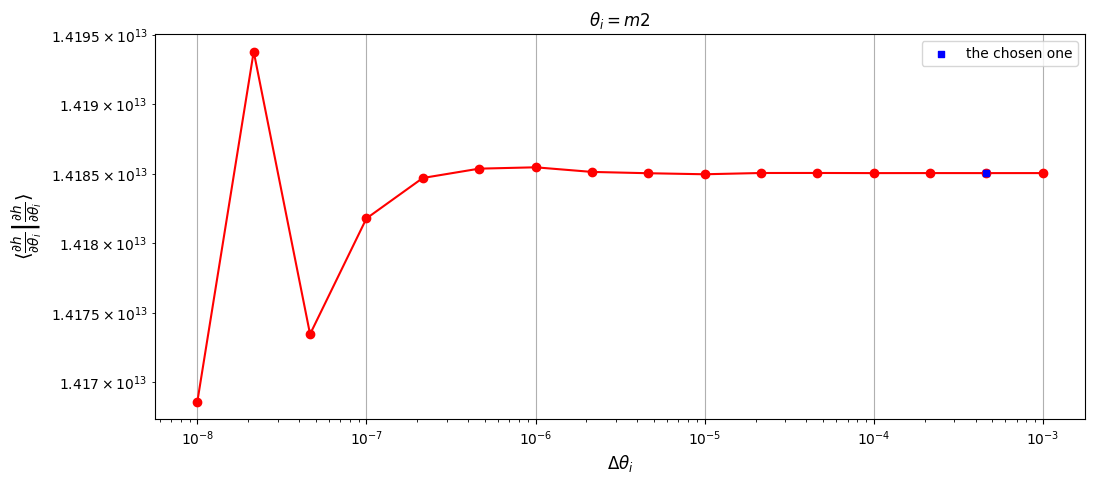

Gamma_ii for a: 1815248042677700.5
Gamma_ii for a: 1815247821010231.2
Gamma_ii for a: 1815248279923799.8
Gamma_ii for a: 1815246475103913.8
Gamma_ii for a: 1815248267550065.0
Gamma_ii for a: 1815251583288523.5
Gamma_ii for a: 1815252453897320.0
Gamma_ii for a: 1815250828757375.2
Gamma_ii for a: 1815222289415366.5
Gamma_ii for a: 1815281048788359.2
Gamma_ii for a: 1815329160738880.8
Gamma_ii for a: 1815793688906601.8
Gamma_ii for a: 1814650413618858.0
Gamma_ii for a: 1815040630613080.5
Gamma_ii for a: 1816612221981168.8
Gamma_ii for a: 1820302777561087.2
[np.float64(1.221141635232133e-07), np.float64(2.528103585473521e-07), np.float64(9.94256102822997e-07), np.float64(9.874385687579585e-07), np.float64(1.8265999539816861e-06), np.float64(4.796075579629797e-07), np.float64(8.952701847063664e-07), np.float64(1.5722229820096438e-05), np.float64(3.2369297873720415e-05), np.float64(2.6503155219473986e-05), np.float64(0.00025582651297831105), np.float64(0.0006300250886691607), np.float64(0.00

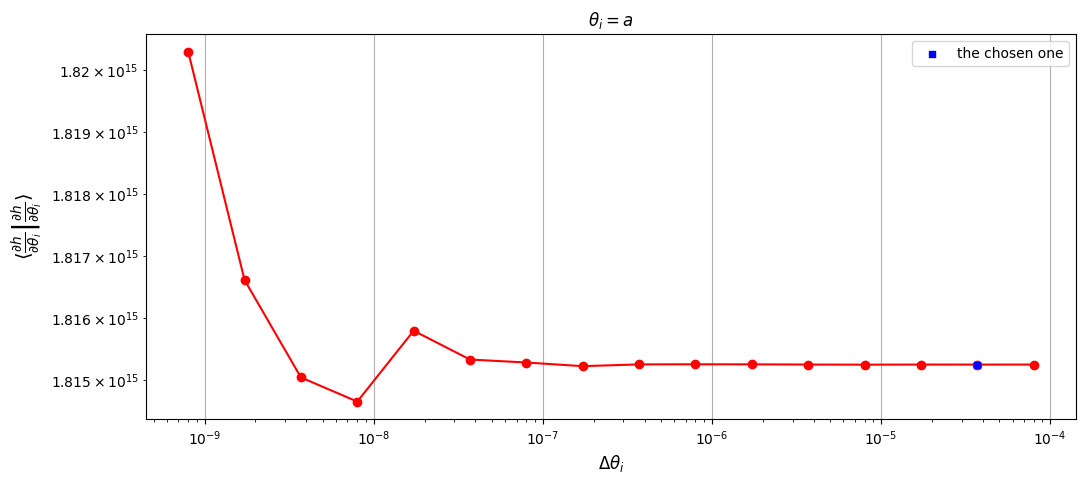

Gamma_ii for p0: 1172653101312323.0
Gamma_ii for p0: 1172653086191227.8
Gamma_ii for p0: 1172653128953071.5
Gamma_ii for p0: 1172653143107410.8
Gamma_ii for p0: 1172653117593530.2
Gamma_ii for p0: 1172653098291654.0
Gamma_ii for p0: 1172652867575194.2
Gamma_ii for p0: 1172653823033827.2
Gamma_ii for p0: 1172653927766907.2
Gamma_ii for p0: 1172658797706183.0
Gamma_ii for p0: 1172678188179041.2
Gamma_ii for p0: 1172658095159897.5
Gamma_ii for p0: 1172642762603499.5
Gamma_ii for p0: 1172843461381810.0
Gamma_ii for p0: 1172415015581243.0
Gamma_ii for p0: 1172271503744731.5
[np.float64(1.2894772911154188e-08), np.float64(3.646589319057818e-08), np.float64(1.2070354591377678e-08), np.float64(2.1757397918626202e-08), np.float64(1.6460005331601803e-08), np.float64(1.967474485668332e-07), np.float64(8.147831987858859e-07), np.float64(8.931286334361572e-08), np.float64(4.152903884127251e-06), np.float64(1.6535203821229016e-05), np.float64(1.713459296165113e-05), np.float64(1.3075215135391007e-05

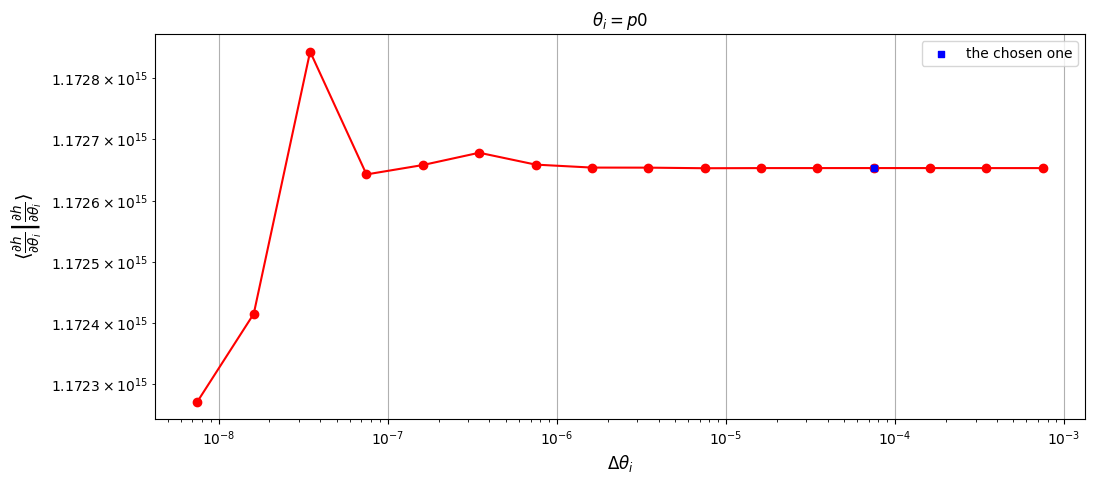

Gamma_ii for e0: 3817522559908868.5
Gamma_ii for e0: 3817522491037662.5
Gamma_ii for e0: 3817523145531645.0
Gamma_ii for e0: 3817520453903421.5
Gamma_ii for e0: 3817523307440442.0
Gamma_ii for e0: 3817518184164071.0
Gamma_ii for e0: 3817510638135272.5
Gamma_ii for e0: 3817602591386169.0
Gamma_ii for e0: 3817523411115367.0
Gamma_ii for e0: 3817725362521220.5
Gamma_ii for e0: 3817224158493088.0
Gamma_ii for e0: 3818361918317965.5
Gamma_ii for e0: 3818035721770184.5
Gamma_ii for e0: 3813958908608430.0
Gamma_ii for e0: 3817100788587620.0
Gamma_ii for e0: 3807744198400607.0
[np.float64(1.8040812113533804e-08), np.float64(1.7144466648907568e-07), np.float64(7.050723777387507e-07), np.float64(7.474838503116378e-07), np.float64(1.3420437372774043e-06), np.float64(1.9766883484536888e-06), np.float64(2.4086648281300498e-05), np.float64(2.0741266594843454e-05), np.float64(5.289835875468307e-05), np.float64(0.00013130065391034267), np.float64(0.0002979706610364208), np.float64(8.543569823641228e-0

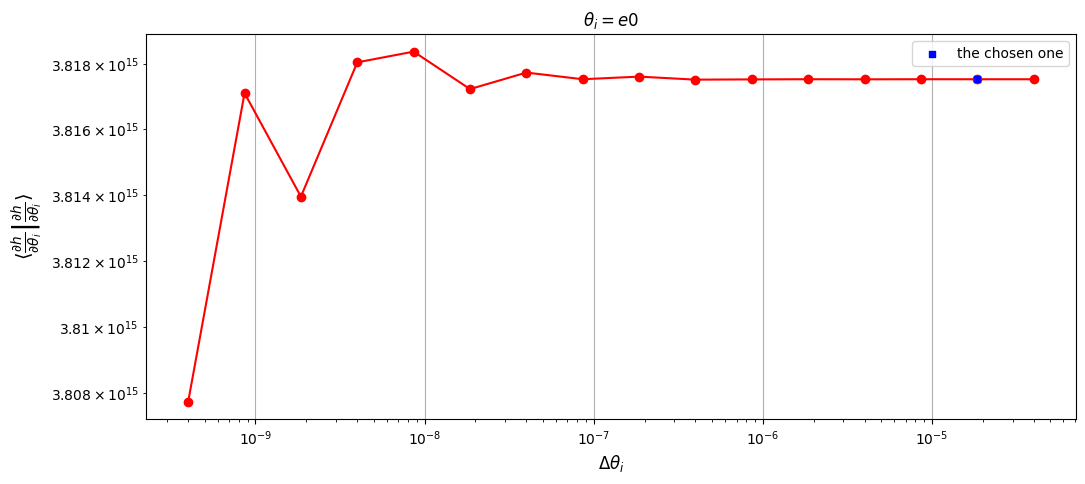

Gamma_ii for qS: 57458.94783534537
Gamma_ii for qS: 57458.94793149193
Gamma_ii for qS: 57458.94793170302
Gamma_ii for qS: 57458.94793170359
Gamma_ii for qS: 57458.94793170246
Gamma_ii for qS: 57458.947931704075
Gamma_ii for qS: 57458.947931702285
Gamma_ii for qS: 57458.94793168984
Gamma_ii for qS: 57458.9479317176
Gamma_ii for qS: 57458.947931744915
Gamma_ii for qS: 57458.94793157778
Gamma_ii for qS: 57458.94793151507
Gamma_ii for qS: 57458.94793175452
Gamma_ii for qS: 57458.947932281386
Gamma_ii for qS: 57458.9479336078
Gamma_ii for qS: 57458.947933819734
[np.float64(1.6733087964725662e-09), np.float64(3.6737547397073105e-12), np.float64(9.877046384157156e-15), np.float64(1.962746396851781e-14), np.float64(2.811159355490859e-14), np.float64(3.1150684750034814e-14), np.float64(2.165352476527279e-13), np.float64(4.830888712250046e-13), np.float64(4.753645144371704e-13), np.float64(2.9087901601406513e-12), np.float64(1.0914136254529466e-12), np.float64(4.167353801311845e-12), np.float64(

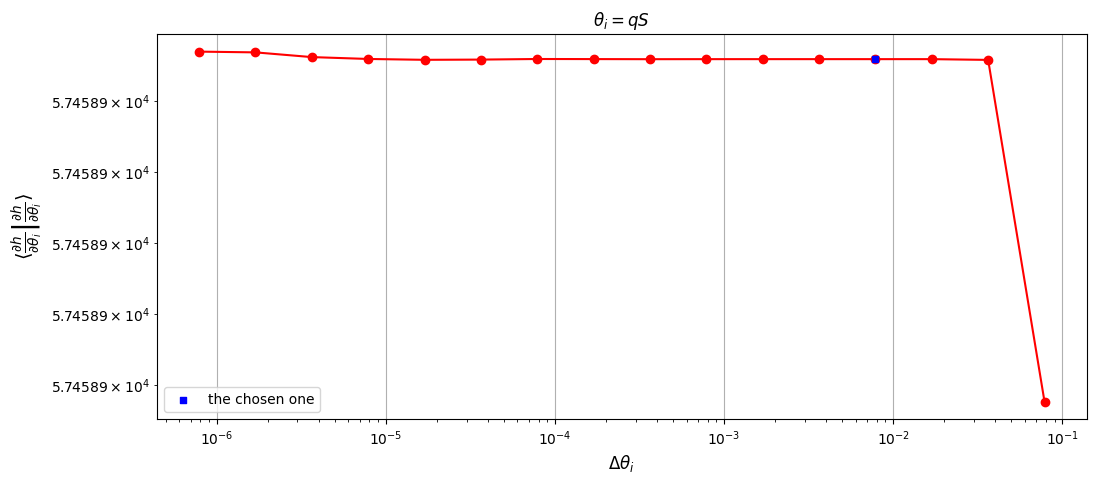

Gamma_ii for phiS: 1108983.0978544678
Gamma_ii for phiS: 1108983.0978177341
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.0978176533
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.0978176533
Gamma_ii for phiS: 1108983.0978176545
Gamma_ii for phiS: 1108983.0978176524
Gamma_ii for phiS: 1108983.0978176494
Gamma_ii for phiS: 1108983.0978176456
Gamma_ii for phiS: 1108983.097817586
Gamma_ii for phiS: 1108983.09781766
[np.float64(3.312376060695232e-11), np.float64(7.306248774304525e-14), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(2.0994967742254377e-16), np.float64(2.0994967742254382e-16), np.float64(2.0994967742254377e-16), np.float64(1.0497483871127179e-15), np.float64(1.8895470968028957e-15), np.float64(2.729345806493079e-15), np.float64(3.3591948387607236e-15), np.float64(

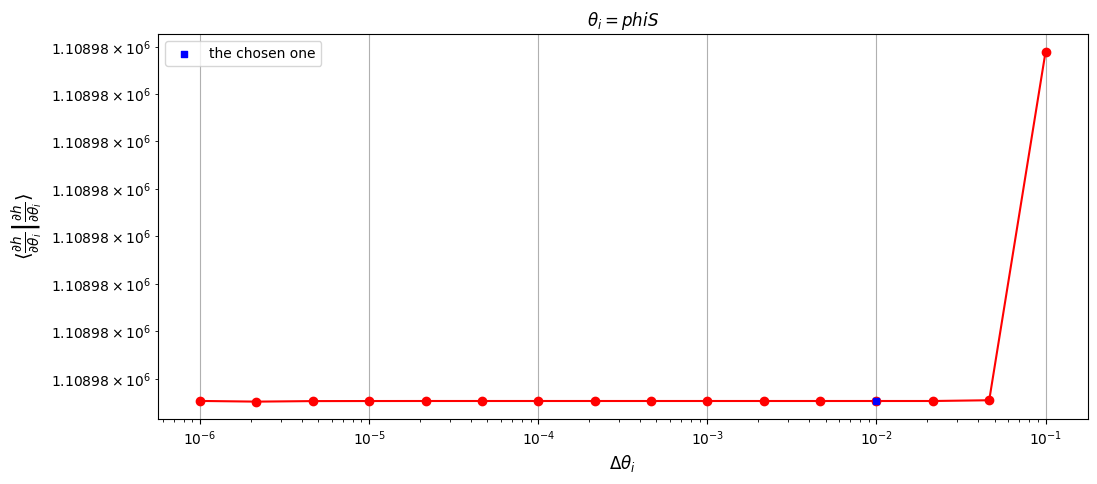

Gamma_ii for dev0p: 97.88417484638582
Gamma_ii for dev0p: 124.77833836891031
Gamma_ii for dev0p: 123.28135441183882
Gamma_ii for dev0p: 720.600784984699
Gamma_ii for dev0p: 591.0584287652766
Gamma_ii for dev0p: 314.6561334343936
Gamma_ii for dev0p: 12972.89852408006
Gamma_ii for dev0p: 8458.439289421554
Gamma_ii for dev0p: 112592.92380005268
Gamma_ii for dev0p: 753707.2979652577
Gamma_ii for dev0p: 306420.0425540284
Gamma_ii for dev0p: 5089814.151895352
Gamma_ii for dev0p: 16760731.591823218
Gamma_ii for dev0p: 213260643.24704337
Gamma_ii for dev0p: 476188430.3341177
Gamma_ii for dev0p: 5433078263.729015
[np.float64(0.21553551581213737), np.float64(0.01214282536246808), np.float64(0.8289186509636448), np.float64(0.21917013600505933), np.float64(0.878426529665958), np.float64(0.9757451171879334), np.float64(0.5337224847501665), np.float64(0.9248759246678555), np.float64(0.8506145235637048), np.float64(1.4597193175846614), np.float64(0.9397974005711145), np.float64(0.6963250605135616), n

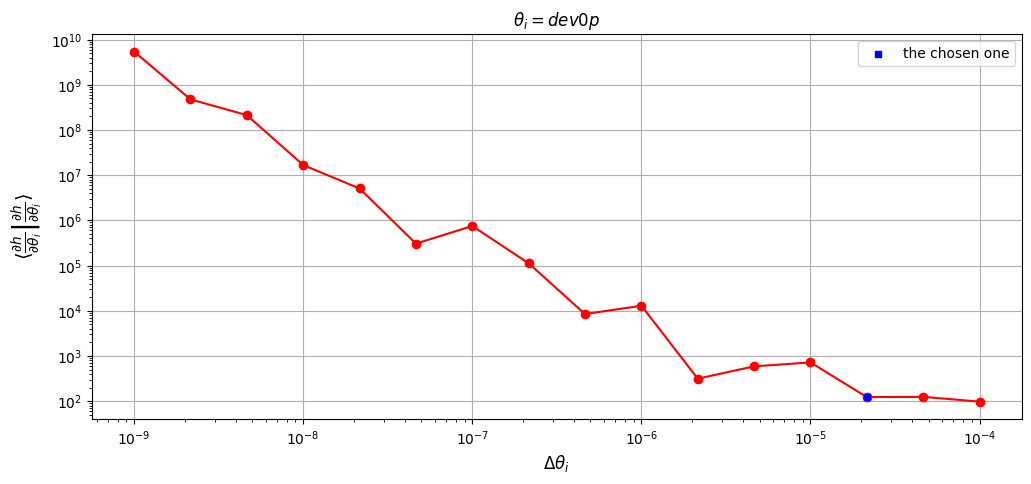

Gamma_ii for dev0e: 1.2422943650084168
Gamma_ii for dev0e: 1.5242809773779884
Gamma_ii for dev0e: 2.479346318230821
Gamma_ii for dev0e: 75.09008578609142
Gamma_ii for dev0e: 357.4230417018104
Gamma_ii for dev0e: 499.75123444793144
Gamma_ii for dev0e: 3669.988319488194
Gamma_ii for dev0e: 10558.491773949845
Gamma_ii for dev0e: 89826.81663417154
Gamma_ii for dev0e: 555435.6445860448
Gamma_ii for dev0e: 8506031.69151832
Gamma_ii for dev0e: 12725448.827885542
Gamma_ii for dev0e: 89818547.8825134
Gamma_ii for dev0e: 97553855.7672036
Gamma_ii for dev0e: 376306944.08480704
Gamma_ii for dev0e: 114104453.19935076
[np.float64(0.1849964780473968), np.float64(0.3852085260659896), np.float64(0.9669817088064898), np.float64(0.7899125769044926), np.float64(0.2847980813961352), np.float64(0.8638275681167221), np.float64(0.6524135834870967), np.float64(0.8824572419509161), np.float64(0.8382768237693538), np.float64(0.9347009669456215), np.float64(0.3315731486909228), np.float64(0.8583204791450093), np.

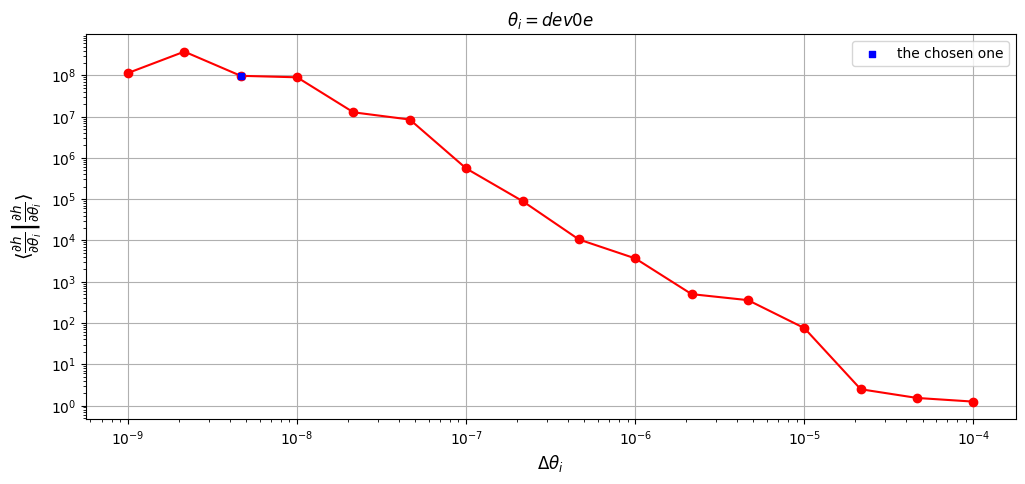

stable deltas: {'m1': 21.544346900318843, 'm2': 0.00046415888336127773, 'a': 3.713271066890227e-05, 'p0': 7.500000000000001e-05, 'e0': 1.8566355334451135e-05, 'qS': 0.007853981633974485, 'phiS': 0.01, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 2.1544346900318823e-05, 'dev0e': 4.641588833612792e-09}
Time taken to compute stable deltas is 369.1773226261139 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 24.524723291397095 seconds


In [7]:
evolve_1PA = True
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']

add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]


sef_true = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef_true.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher_true = sef_true(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )

In [8]:
# def logmasstransform(Fisher, m1, index_of_m1 = 0):    
#     J = np.eye(len(Fisher))
#     J[index_of_m1,index_of_m1] = m1
    
#     return J.T@Fisher@J
param_true= [m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_0_p,dev_0_e] 
param_0v1_bf = best_fit_0pa_vs_1pa.copy()
param_0v1_bf[0] = np.exp(param_0v1_bf[0])
param_bf = best_fit_with_deviation.copy()
param_bf[0] = np.exp(param_bf[0])

Cov_bf = np.linalg.inv(Fisher_bf)
Cov_0v1_bf = np.linalg.inv(Fisher_0v1_bf)
Cov_true = np.linalg.inv(Fisher_true)

In [9]:
Cov_0v1_bf

array([[ 2.20171743e+02,  1.33153824e-03,  1.49362999e-04,
        -9.07487310e-04, -4.95644167e-05, -2.46122964e-04,
        -3.77347394e-04, -2.00898758e-01,  5.36588605e-02],
       [ 1.33153824e-03,  8.24780125e-09,  9.02585753e-10,
        -5.45437581e-09, -3.06499247e-10, -1.21247699e-09,
        -5.04473563e-09, -1.12501045e-06,  1.51074153e-07],
       [ 1.49362999e-04,  9.02585753e-10,  1.01447325e-10,
        -6.16007216e-10, -3.35207409e-11, -1.59905174e-10,
        -3.31091432e-10, -1.32360038e-07,  3.50272126e-08],
       [-9.07487310e-04, -5.45437581e-09, -6.16007216e-10,
         3.74683217e-09,  2.02943400e-10,  1.04977845e-09,
         1.24895961e-09,  8.34381437e-07, -2.47662637e-07],
       [-4.95644167e-05, -3.06499247e-10, -3.35207409e-11,
         2.02943400e-10,  1.14522872e-11,  5.17719969e-11,
         1.21031723e-10,  4.55008177e-08, -6.99578002e-09],
       [-2.46122964e-04, -1.21247699e-09, -1.59905174e-10,
         1.04977845e-09,  5.17719970e-11,  1.850624

15.01954290794807 14.966483235183663 14.838185291065598


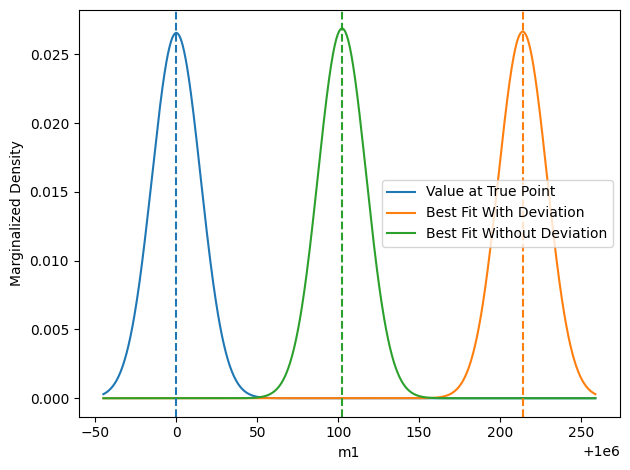

9.516590857717476e-05 9.527872023438672e-05 9.081740609055284e-05


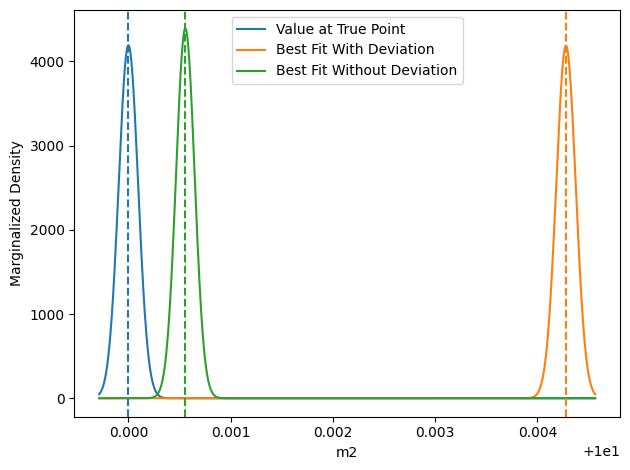

1.0196535206066732e-05 1.0131141118768779e-05 1.0072106263861652e-05


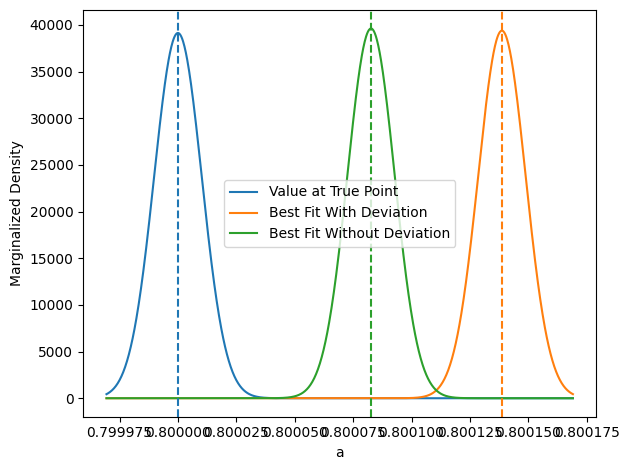

6.18981422089457e-05 6.138110577447863e-05 6.121137287784941e-05


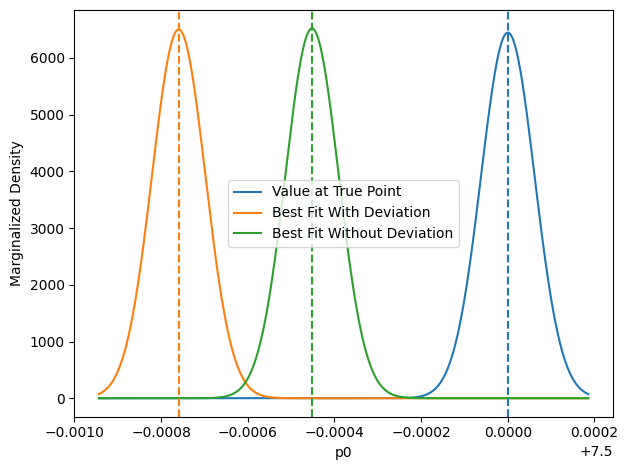

3.5344961256472124e-06 3.5190761688374905e-06 3.3841228150885596e-06


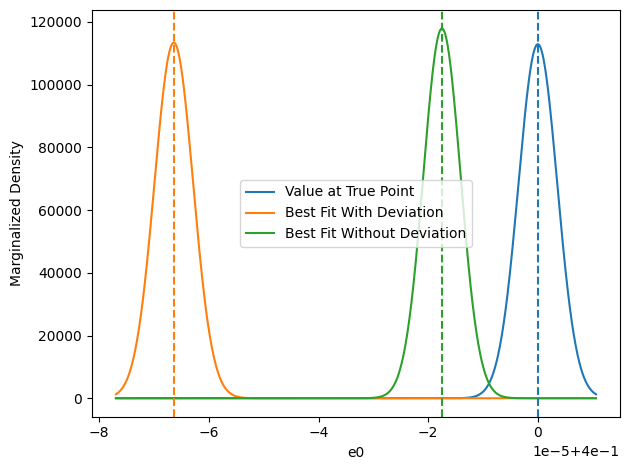

0.013605675471431287 0.013597997489584648 0.013603767325661837


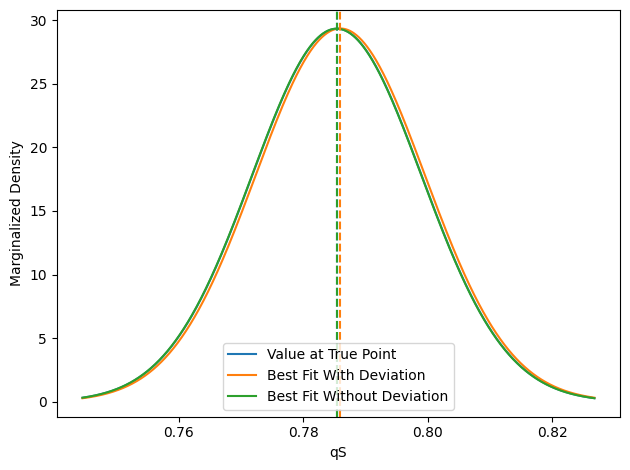

0.017207461179243908 0.017191310866560342 0.01720528356888283


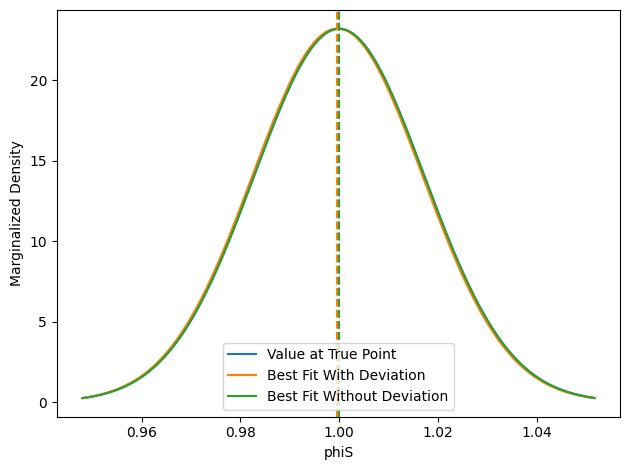

0.07009057911240493 0.07032726319882714 0.06999202877423526


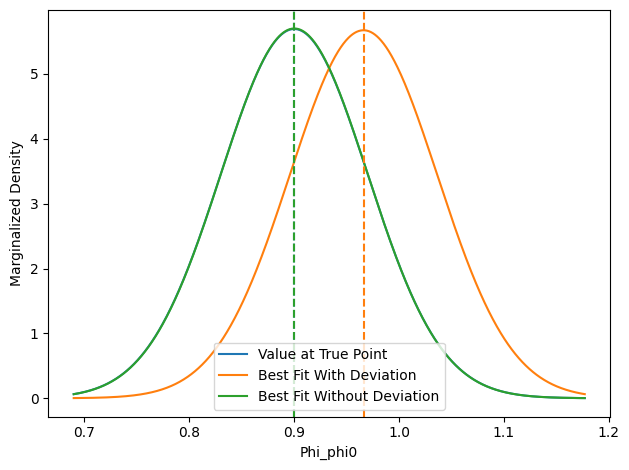

In [10]:
# FOR FIRST EIGHT PARAMETERS ONLY (DOES NOT INCLUDE DEVIATION PARAMETERS)
from scipy.stats import norm

npar = 8
for i in range(npar):

    mu1, sigma1 = param_true[i], np.sqrt(Cov_true[i, i])
    mu2, sigma2 = param_bf[i], np.sqrt(Cov_bf[i, i])
    mu3, sigma3 = param_0v1_bf[i], np.sqrt(Cov_0v1_bf[i, i])

    print(sigma1,sigma2,sigma3)

    # x-range covering all three posteriors
    xmin = min(mu1 - 3*sigma1, mu2 - 3*sigma2, mu3 - 3*sigma3)
    xmax = max(mu1 + 3*sigma1, mu2 + 3*sigma2, mu3 + 3*sigma3)
    x = np.linspace(xmin, xmax, 1000)

    plt.figure()

    line1, = plt.plot(x, norm.pdf(x, mu1, sigma1), label="Value at True Point")
    line2, = plt.plot(x, norm.pdf(x, mu2, sigma2), label="Best Fit With Deviation")
    line3, = plt.plot(x, norm.pdf(x, mu3, sigma3), label="Best Fit Without Deviation")

    plt.axvline(mu1, linestyle="--", color=line1.get_color())
    plt.axvline(mu2, linestyle="--", color=line2.get_color())
    plt.axvline(mu3, linestyle="--", color=line3.get_color())

    plt.xlabel(param_names[i])
    plt.ylabel("Marginalized Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

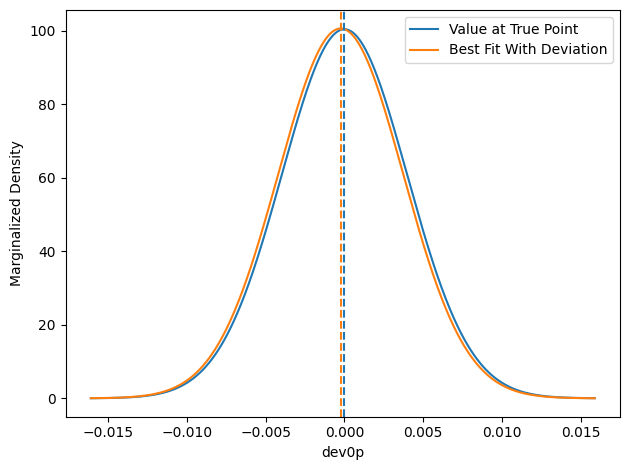

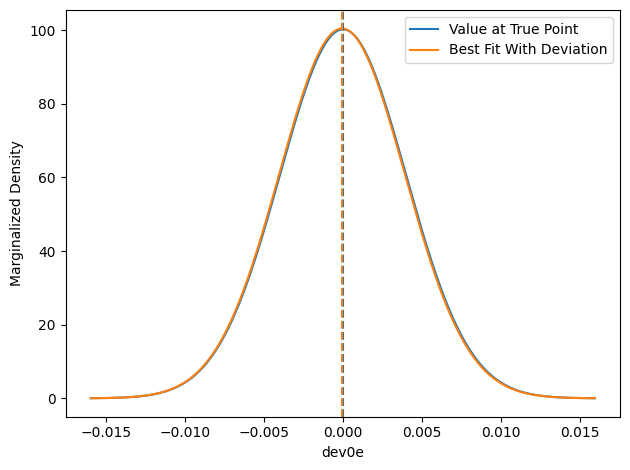

In [23]:
npar = 8
for i in range(npar+1,11):

    mu1, sigma1 = param_true[i], np.sqrt(Cov_true[i, i])
    mu2, sigma2 = param_bf[i], np.sqrt(Cov_bf[i, i])

    # x-range covering all three posteriors
    xmin = min(mu1 - 4*sigma1, mu2 - 4*sigma2)
    xmax = max(mu1 + 4*sigma1, mu2 + 4*sigma2)
    x = np.linspace(xmin, xmax, 500)

    plt.figure()


    line1, = plt.plot(x, norm.pdf(x, mu1, sigma1), label="Value at True Point")
    line2, = plt.plot(x, norm.pdf(x, mu2, sigma2), label="Best Fit With Deviation")

    plt.axvline(mu1, linestyle="--", color=line1.get_color())
    plt.axvline(mu2, linestyle="--", color=line2.get_color())


    plt.xlabel(param_names[i])
    plt.ylabel("Marginalized Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

0.0397319442032956 0.03969967030133748 9.081740609055284e-05


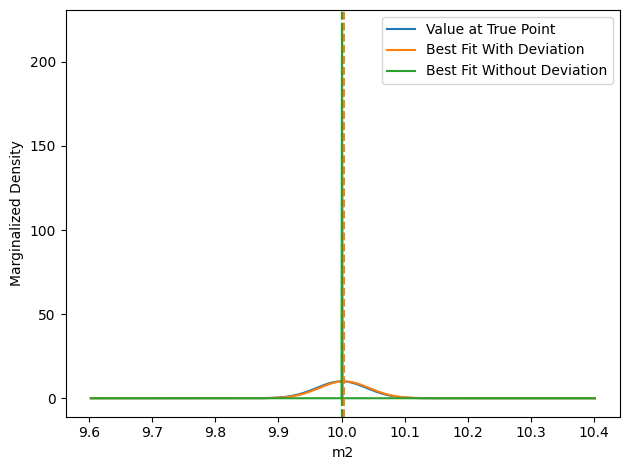

In [25]:
mu1, sigma1 = param_true[1], np.sqrt(Cov_true[1, 1])
mu2, sigma2 = param_bf[1], np.sqrt(Cov_bf[1, 1])
mu3, sigma3 = param_0v1_bf[1], np.sqrt(Cov_0v1_bf[1, 1])
print(sigma1,sigma2,sigma3)
# x-range covering all three posteriors
xmin = min(mu1 - 10*sigma1, mu2 - 10*sigma2, mu3 - 10*sigma3)
xmax = max(mu1 + 10*sigma1, mu2 + 10*sigma2, mu3 + 10*sigma3)
x = np.linspace(xmin, xmax, 1000)
plt.figure()

line1, = plt.plot(x, norm.pdf(x, mu1, sigma1), label="Value at True Point")
line2, = plt.plot(x, norm.pdf(x, mu2, sigma2), label="Best Fit With Deviation")
line3, = plt.plot(x, norm.pdf(x, mu3, sigma3), label="Best Fit Without Deviation")
plt.axvline(mu1, linestyle="--", color=line1.get_color())
plt.axvline(mu2, linestyle="--", color=line2.get_color())
plt.axvline(mu3, linestyle="--", color=line3.get_color())

plt.xlabel(param_names[1])
plt.ylabel("Marginalized Density")
plt.legend()
plt.tight_layout()
plt.show()

0.0397319442032956 0.03969967030133748 9.081740609055284e-05


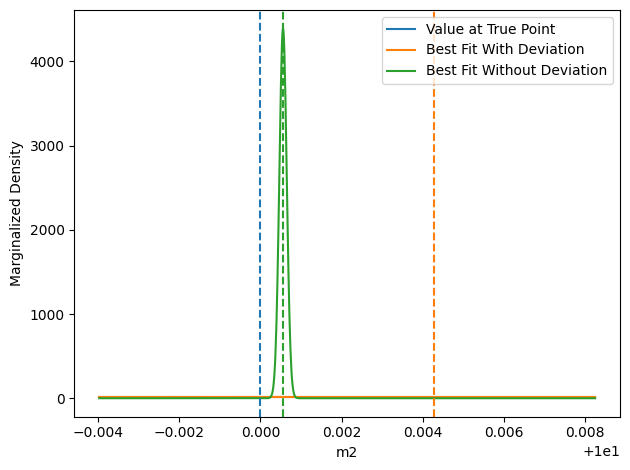

In [26]:
mu1, sigma1 = param_true[1], np.sqrt(Cov_true[1, 1])
mu2, sigma2 = param_bf[1], np.sqrt(Cov_bf[1, 1])
mu3, sigma3 = param_0v1_bf[1], np.sqrt(Cov_0v1_bf[1, 1])
print(sigma1,sigma2,sigma3)
# x-range covering all three posteriors
xmin = min(mu1 - 0.1*sigma1, mu2 - 0.1*sigma2, mu3 - 0.1*sigma3)
xmax = max(mu1 + 0.1*sigma1, mu2 + 0.1*sigma2, mu3 + 0.1*sigma3)
x = np.linspace(xmin, xmax, 1000)
plt.figure()

line1, = plt.plot(x, norm.pdf(x, mu1, sigma1), label="Value at True Point")
line2, = plt.plot(x, norm.pdf(x, mu2, sigma2), label="Best Fit With Deviation")
line3, = plt.plot(x, norm.pdf(x, mu3, sigma3), label="Best Fit Without Deviation")
plt.axvline(mu1, linestyle="--", color=line1.get_color())
plt.axvline(mu2, linestyle="--", color=line2.get_color())
plt.axvline(mu3, linestyle="--", color=line3.get_color())

plt.xlabel(param_names[1])
plt.ylabel("Marginalized Density")
plt.legend()
plt.tight_layout()
plt.show()